---
# PROYECTO: EduAI Risk Docente - SPRINT 1: Datos y Dashboard Exploratorio
# EQUIPO: 5
# CURSO: Administración del Desarrollo de Software
# OBTENIBLE: Dataset limpio (US01, US02) y Visualizaciones Base (US03)
---


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

# Configuración de estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ------------------------------------------------------------------------------
# 1. CARGA DE DATOS (US01)
# ------------------------------------------------------------------------------
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/MNA/SCRUM/student-mat.csv'

print("=== FASE 1: CARGA Y EXPLORACIÓN INICIAL (US01) ===")
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"No se encontró el archivo '{DATA_PATH}' en el entorno actual de Colab. Por favor, súbelo a la pestaña de archivos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== FASE 1: CARGA Y EXPLORACIÓN INICIAL (US01) ===


In [ ]:
# Cargar el dataset (el repositorio de UCI/Kaggle usa separador ';')
df_raw = pd.read_csv(DATA_PATH, sep=";")

# Registrar dimensiones básicas
num_registros, num_columnas = df_raw.shape
print(f"-> Fuente registrada exitosamente: {DATA_PATH}")
print(f"-> Número de registros (estudiantes): {num_registros}")
print(f"-> Número de columnas (atributos iniciales): {num_columnas}\n")

-> Fuente registrada exitosamente: /content/drive/MyDrive/Colab Notebooks/MNA/SCRUM/student-mat.csv
-> Número de registros (estudiantes): 395
-> Número de columnas (atributos iniciales): 33



In [ ]:
# ------------------------------------------------------------------------------
# 2. LIMPIEZA Y PREPARACIÓN DE DATOS (US02)
# ------------------------------------------------------------------------------
print("=== FASE 2: CALIDAD Y LIMPIEZA DE DATOS (US02) ===")

# Verificar valores nulos/faltantes en columnas críticas
required_cols = ["G1", "G2", "G3", "absences", "studytime", "failures"]
missing_values = df_raw[required_cols].isnull().sum()
print("Valores faltantes por variable crítica:")
print(missing_values)

# Clonar el dataset para trabajar la versión limpia de forma separada
df_clean = df_raw.copy()

=== FASE 2: CALIDAD Y LIMPIEZA DE DATOS (US02) ===
Valores faltantes por variable crítica:
G1           0
G2           0
G3           0
absences     0
studytime    0
failures     0
dtype: int64


In [ ]:
# Ingeniería de Características: Definición estricta de la Variable Objetivo del MVP
# Se define aprobado si la nota final G3 es >= 10, de lo contrario reprueba (0)
df_clean["aprueba"] = (df_clean["G3"] >= 10).astype(int)
df_clean["resultado"] = df_clean["aprueba"].map({1: "Aprueba", 0: "Reprueba"})

print("\n-> Variable objetivo 'aprueba' definida de forma binaria (G3 >= 10).")
print(df_clean["resultado"].value_counts(dropna=False))

# Guardar el dataset limpio en un archivo nuevo para el Sprint 2
CLEAN_DATA_PATH = "student-mat-clean.csv"
df_clean.to_csv(CLEAN_DATA_PATH, index=False)
print(f"\n-> Dataset limpio guardado con éxito como: '{CLEAN_DATA_PATH}'")


-> Variable objetivo 'aprueba' definida de forma binaria (G3 >= 10).
resultado
Aprueba     265
Reprueba    130
Name: count, dtype: int64

-> Dataset limpio guardado con éxito como: 'student-mat-clean.csv'



=== FASE 3: GENERACIÓN DE VISUALIZACIONES EXPLORATORIAS (US03) ===


/tmp/ipykernel_1522/1127540671.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="resultado", data=df_clean, palette={"Aprueba": "#2ecc71", "Reprueba": "#e74c3c"})


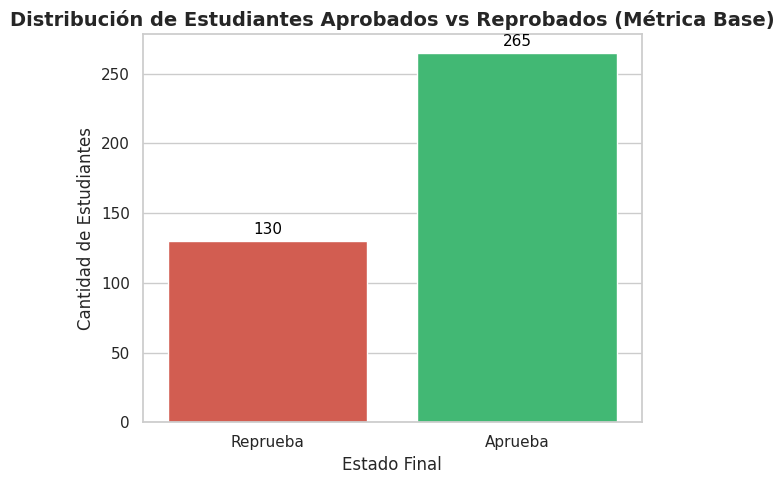

In [ ]:
# ------------------------------------------------------------------------------
# 3. VISUALIZACIONES EXPLORATORIAS - REQUISITO MÍNIMO (US03)
# ------------------------------------------------------------------------------
print("\n=== FASE 3: GENERACIÓN DE VISUALIZACIONES EXPLORATORIAS (US03) ===")

# Visualización 1: Distribución del Resultado Final (Aprobados vs Reprobados)
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="resultado", data=df_clean, palette={"Aprueba": "#2ecc71", "Reprueba": "#e74c3c"})
plt.title("Distribución de Estudiantes Aprobados vs Reprobados (Métrica Base)", fontsize=14, fontweight='bold')
plt.xlabel("Estado Final", fontsize=12)
plt.ylabel("Cantidad de Estudiantes", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig("visualizacion_1_resultados.png")
plt.show()

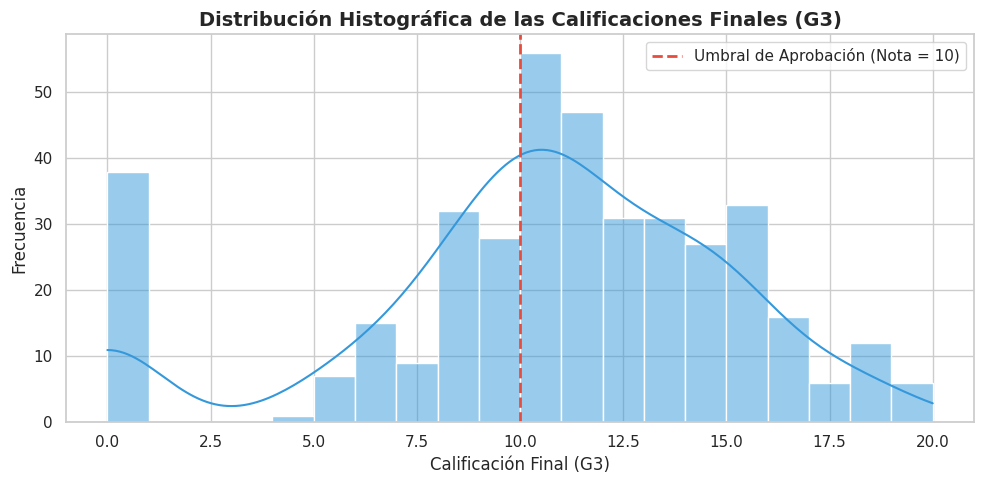

In [ ]:
# Visualización 2: Distribución Histográfica de la Nota Final (G3)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["G3"], bins=20, kde=True, color="#3498db")
plt.axvline(x=10, color="#e74c3c", linestyle="--", linewidth=2, label="Umbral de Aprobación (Nota = 10)")
plt.title("Distribución Histográfica de las Calificaciones Finales (G3)", fontsize=14, fontweight='bold')
plt.xlabel("Calificación Final (G3)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("visualizacion_2_notas.png")
plt.show()

/tmp/ipykernel_1522/1331759062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="resultado", y="absences", data=df_clean, palette={"Aprueba": "#2ecc71", "Reprueba": "#e74c3c"})


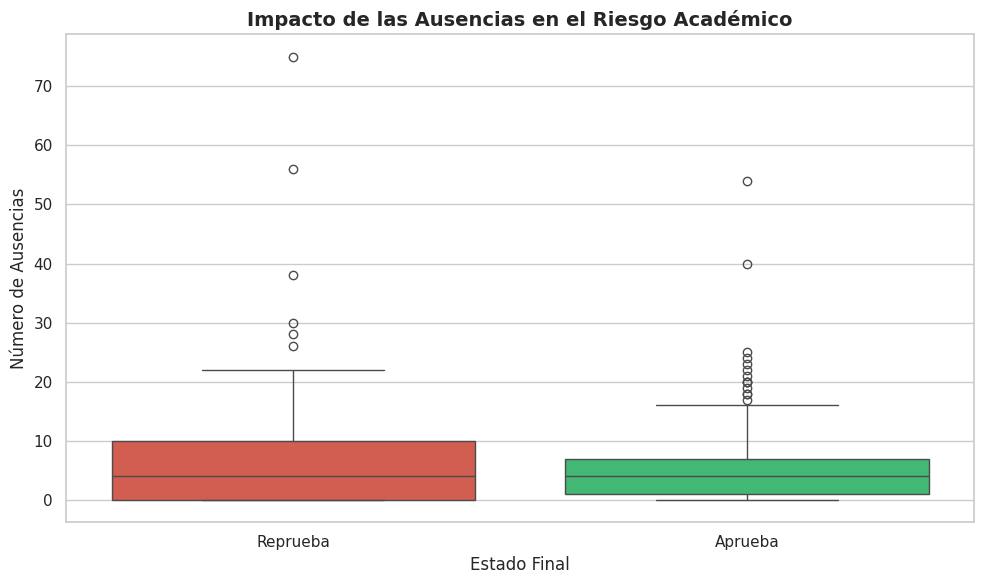

In [ ]:
# Visualización 3: Relación entre Ausencias y Desempeño por Estado de Aprobación
plt.figure(figsize=(10, 6))
sns.boxplot(x="resultado", y="absences", data=df_clean, palette={"Aprueba": "#2ecc71", "Reprueba": "#e74c3c"})
plt.title("Impacto de las Ausencias en el Riesgo Académico", fontsize=14, fontweight='bold')
plt.xlabel("Estado Final", fontsize=12)
plt.ylabel("Número de Ausencias", fontsize=12)
plt.tight_layout()
plt.savefig("visualizacion_3_ausencias.png")
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# MUESTRA DEL DICCIONARIO Y VISTA PREVIA
# ------------------------------------------------------------------------------
print("\n=== VISTA PREVIA DE VARIABLES CLAVE PARA ANÁLISIS DOCENTE ===")
preview_cols = ["G1", "G2", "G3", "absences", "studytime", "failures", "resultado"]
print(df_clean[preview_cols].head(10))
print("\n¡Sprint 1 completado con éxito bajo criterios de la DoD del equipo!")


=== VISTA PREVIA DE VARIABLES CLAVE PARA ANÁLISIS DOCENTE ===
   G1  G2  G3  absences  studytime  failures resultado
0   5   6   6         6          2         0  Reprueba
1   5   5   6         4          2         0  Reprueba
2   7   8  10        10          2         3   Aprueba
3  15  14  15         2          3         0   Aprueba
4   6  10  10         4          2         0   Aprueba
5  15  15  15        10          2         0   Aprueba
6  12  12  11         0          2         0   Aprueba
7   6   5   6         6          2         0  Reprueba
8  16  18  19         0          2         0   Aprueba
9  14  15  15         0          2         0   Aprueba

¡Sprint 1 completado con éxito bajo criterios de la DoD del equipo!
